In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
import matplotlib.pyplot as plt

In [2]:
# Load IMDB dataset
max_features = 10000   # Vocabulary size
max_len = 200          # Maximum review length

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# Pad sequences so all have same length
x_train = sequence.pad_sequences(x_train, maxlen=max_len)
x_test = sequence.pad_sequences(x_test, maxlen=max_len)

print("Training Data Shape:", x_train.shape)
print("Testing Data Shape :", x_test.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training Data Shape: (25000, 200)
Testing Data Shape : (25000, 200)


In [3]:
lstm_model = models.Sequential([
    layers.Input(shape=(max_len,)),
    layers.Embedding(input_dim=max_features, output_dim=128),
    layers.LSTM(64),
    layers.Dense(1, activation='sigmoid')
])

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
lstm_model.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

In [5]:
history_lstm = lstm_model.fit(x_train, y_train,
                              epochs=3,
                              batch_size=64,
                              validation_data=(x_test, y_test))

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.8069 - loss: 0.4114 - val_accuracy: 0.8484 - val_loss: 0.3467
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9036 - loss: 0.2457 - val_accuracy: 0.8656 - val_loss: 0.3284
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9322 - loss: 0.1777 - val_accuracy: 0.8671 - val_loss: 0.3532


In [6]:
loss, acc = lstm_model.evaluate(x_test, y_test)
print("LSTM Test Accuracy:", acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8671 - loss: 0.3532
LSTM Test Accuracy: 0.8670799732208252


In [7]:
gru_model = models.Sequential([
    layers.Input(shape=(max_len,)),
    layers.Embedding(input_dim=max_features, output_dim=128),
    layers.GRU(64),
    layers.Dense(1, activation='sigmoid')
])

gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,313 (5.03 MB)

 Trainable params: 1,317,313 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
gru_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

In [9]:
history_gru = gru_model.fit(x_train, y_train,
                            epochs=3,
                            batch_size=64,
                            validation_data=(x_test, y_test))

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.7748 - loss: 0.4649 - val_accuracy: 0.8534 - val_loss: 0.3486
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8937 - loss: 0.2676 - val_accuracy: 0.8495 - val_loss: 0.3438
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9230 - loss: 0.1976 - val_accuracy: 0.8684 - val_loss: 0.3433


In [10]:
loss, acc = gru_model.evaluate(x_test, y_test)
print("GRU Test Accuracy:", acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8684 - loss: 0.3433
GRU Test Accuracy: 0.8684399724006653


In [11]:
lstm_acc = lstm_model.evaluate(x_test, y_test, verbose=0)[1]
gru_acc = gru_model.evaluate(x_test, y_test, verbose=0)[1]

print("LSTM Accuracy:", lstm_acc)
print("GRU Accuracy :", gru_acc)

LSTM Accuracy: 0.8670799732208252
GRU Accuracy : 0.8684399724006653


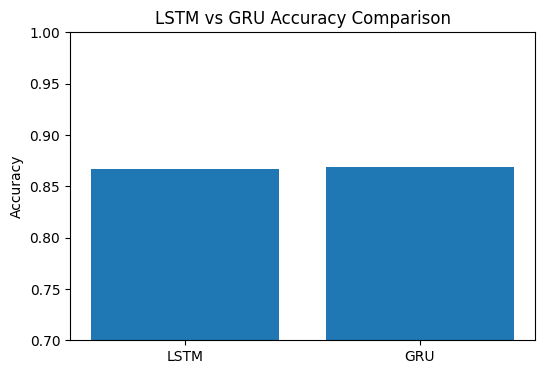

In [12]:
model_names = ['LSTM', 'GRU']
accuracies = [lstm_acc, gru_acc]

plt.figure(figsize=(6, 4))
plt.bar(model_names, accuracies)
plt.title("LSTM vs GRU Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.7, 1.0)
plt.show()